In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datetime import date
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from torchvision import datasets, transforms

import copy
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import plotly.express as px
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import tqdm




def save_my_work(model, logfile, xdata_name, opt, Bsize, learningRate, epoch, second_time, best_mse, mse, loss, init_time):
    #model_save_time = str(int(time.time()))
    model_save_time = str(int(second_time))
    # model_file_name = '/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/'+'model' + model_save_time + '.pt'
    model_file_name = '/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/'+'model' + str(int(second_time)) + '_RMSE_' + str( ((mse**(1/2))//0.0001)*0.0001 ) + '.pt'
    elapsed_time = (time.time()-second_time)/60
    print('start to save model')
    torch.save(model, model_file_name )
    print('start to save log')
    print(
                    model_file_name,
                    'data:', xdata_name,
                    file=logfile
    )
    print(
                    ', layer_dim_list:', dim_list,
                    'activateion:', act,
                    ', optimizer:', opt,
                    ', Bsize:', Bsize ,
                    ', learningRate:', learningRate ,
                    file=logfile
                    )
    print(
                ', epoch: %5d' % epoch,
                ', passed_time: %.3f' % ( ( ( time.time()-second_time ) )  / 60  ),  'm',

                ", minimum_RMSE: %.5f" % ( best_mse**(1/2) ),
                ', RMSE_Test: %5f' % (mse**(1/2)),
                ', RMSE_Train: %5f' % (loss**(1/2)),
                ', passed_time_accum: %.3f' % ( ( time.time() -init_time )  / 60  ),  'm',
                'model_save_time' , model_save_time,
                file=logfile
                )


    print(
                    model_file_name,
                    'data:', xdata_name,
    )
    print(
                    ', layer_dim_list:', dim_list,
                    'activateion:', act,
                    ', optimizer:', opt,
                    ', Bsize:', Bsize ,
                    ', learningRate:', learningRate ,
                    )
    print(
                ', epoch: %5d' % epoch,
                ', passed_time: %.3f' % ( ( ( time.time()-second_time ) )  / 60  ),  'm',

                ", minimum_RMSE: %.5f" % (best_mse**(1/2)),
                ', test_loss: %5f' % (mse**(1/2)),
                ', train_loss: %5f' % (loss**(1/2)),
                ', passed_time_accum: %.3f' % ( ( time.time() -init_time )  / 60  ),  'm',
                'model_save_time' , model_save_time,
                )
    print('start to save figures')

    fig, axs = plt.subplots(2, 1, figsize=(5, 5*2))#, sharey=True)
    axs[0].set_xlabel('Epoch', fontsize=10)
    axs[0].set_ylabel(r'Test Loss', fontsize=10)
    axs[0].legend()
    axs[0].plot(history, )
    axs[0].set_yscale('log')
    axs[0].set_title('Test_Loss')
    axs[0].legend("RMSE:"+str( mse**(1/2) )+ "_"+str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str((elapsed_time//0.001) * 0.001  ))


    axs[1].set_xlabel('Epoch', fontsize=10)
    axs[1].set_ylabel(r'Train Loss', fontsize=10)
    axs[1].legend()
    axs[1].plot(history_train)
    axs[1].set_yscale('log')
    axs[1].set_title('Train_Loss')

    # fig.legend(l1, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper left')
    # fig.legend(l2, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper right')

    # plt.legend([str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time)])#, fontsize="x-large")

    plt.savefig(
                model_file_name[0:-3] + 'Loss' + '.pdf',
                format="pdf",
                bbox_inches="tight"
                )
    plt.show()
    print('saving work is done')

def print_progress(act, opt, batch_size, learningRate, epoch, mse, loss, second_time):
    print(

        'act: ', act ,
        'opt: ', opt ,
        'batch_size: ', batch_size ,
        'learningRate: ', learningRate ,
        'epoch: %5d' % epoch,
        ', RMSE_Test: {:7.5f}'.format(mse**(1/2)),
        ', RMSE_Train: {:7.5f}'.format(loss**(1/2)),
        ', est_time: {:5.1f}'.format(( ( ( time.time()-second_time ) )  / 60  )),  'min,',
        'average_time: {:.2f}'.format( ( time.time()-second_time )/(epoch+1)), 's'
        )

In [ ]:
data_path = '/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx'

pd_read = pd.read_excel(data_path)
x_np_array = np.array([])
y_np_array = np.array([])
pd_read_keys = pd_read.keys()
len_pd_read_keys = len(pd_read.keys())
for i in range(len_pd_read_keys):
    if 0 < i and i < 7:
        x_np_array = np.append(x_np_array, pd_read[ pd_read_keys[i] ])
    if i == 7:
        y_np_array = np.append(y_np_array, pd_read[ pd_read_keys[i] ])

x_np_array = x_np_array.reshape(6, 136).T



X_train, X_test, y_train, y_test = train_test_split(x_np_array, y_np_array, train_size=0.8, shuffle=True)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)




In [ ]:
float(0.01232143)//0.001

12.0

In [ ]:
(float(0.01232143)//0.001)*0.001

0.012

start
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0001 epoch:     0 , RMSE_Test: 1.12267 , RMSE_Train: 0.79781 , est_time:   0.0 min, average_time: 0.03 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0001 epoch:  1000 , RMSE_Test: 0.17004 , RMSE_Train: 0.11234 , est_time:   0.4 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0001 epoch:  2000 , RMSE_Test: 0.16196 , RMSE_Train: 0.10644 , est_time:   0.8 min, average_time: 0.03 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0001 epoch:  3000 , RMSE_Test: 0.16884 , RMSE_Train: 0.10464 , est_time:   1.2 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0001 epoch:  4000 , RMSE_Test: 0.18000 , RMSE_Train: 0.10078 , est_time:   1.6 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0001 epoch:  5000 , RMSE_Test: 0.18353 , RMSE_Train: 0.09793 , est_time:   2.0 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 lea

act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0001 epoch: 23317 , RMSE_Test: 0.17983 , RMSE_Train: 0.05117 , est_time:  10.0 min, average_time: 0.03 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691726083_RMSE_0.17980000000000002.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.0001
, epoch: 23317 , passed_time: 10.001 m , minimum_RMSE: 0.13251 , test_loss: 0.179831 , train_loss: 0.051169 , passed_time_accum: 10.001 m model_save_time 1691726083
start to save figures


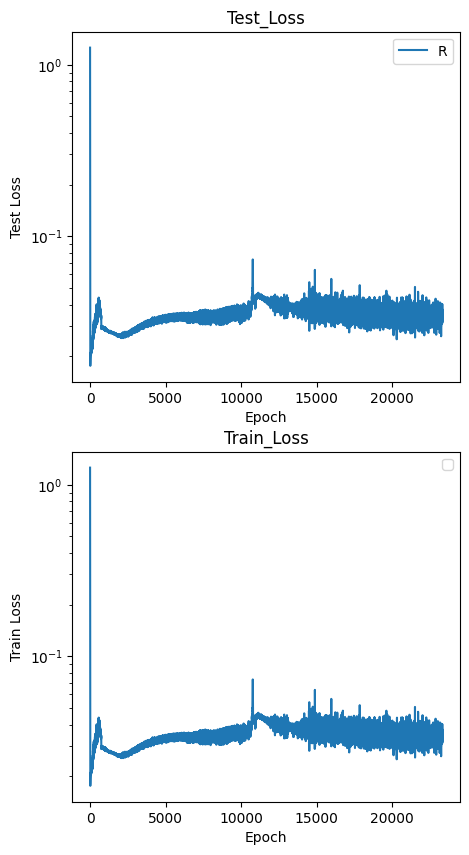

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0005 epoch:     0 , RMSE_Test: 0.26962 , RMSE_Train: 0.41655 , est_time:   0.0 min, average_time: 0.03 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0005 epoch:  1000 , RMSE_Test: 0.16124 , RMSE_Train: 0.07898 , est_time:   0.4 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0005 epoch:  2000 , RMSE_Test: 0.14234 , RMSE_Train: 0.08096 , est_time:   0.8 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0005 epoch:  3000 , RMSE_Test: 0.13364 , RMSE_Train: 0.06734 , est_time:   1.2 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0005 epoch:  4000 , RMSE_Test: 0.20484 , RMSE_Train: 0.07747 , est_time:   1.6 min, average_time: 0.02 s
act:  ReLU opt:  Adam bat

act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0005 epoch: 19752 , RMSE_Test: 0.15465 , RMSE_Train: 0.05256 , est_time:  10.0 min, average_time: 0.03 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691726685_RMSE_0.15460000000000002.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.0005
, epoch: 19752 , passed_time: 10.000 m , minimum_RMSE: 0.10346 , test_loss: 0.154654 , train_loss: 0.052564 , passed_time_accum: 20.033 m model_save_time 1691726685
start to save figures


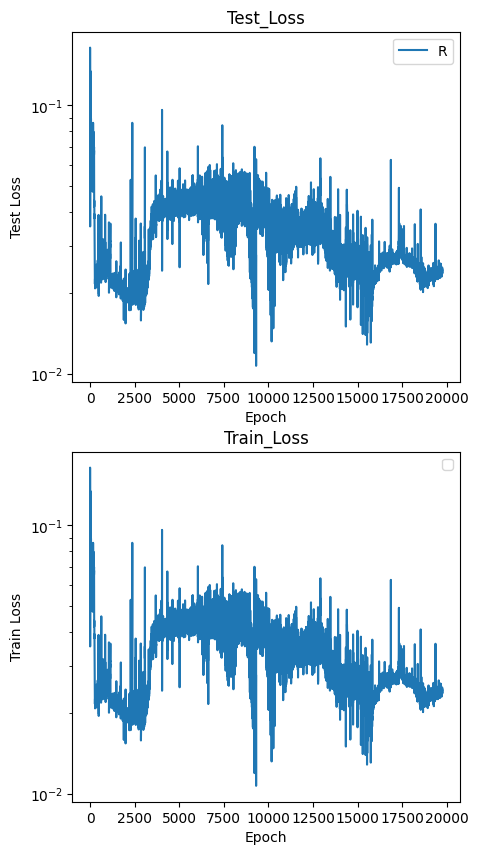

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  8 learningRate:  1e-05 epoch:     0 , RMSE_Test: 0.98303 , RMSE_Train: 0.99867 , est_time:   0.0 min, average_time: 0.03 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  1e-05 epoch:  1000 , RMSE_Test: 0.13001 , RMSE_Train: 0.07753 , est_time:   0.4 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  1e-05 epoch:  2000 , RMSE_Test: 0.13918 , RMSE_Train: 0.08005 , est_time:   0.8 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  1e-05 epoch:  3000 , RMSE_Test: 0.14513 , RMSE_Train: 0.07045 , est_time:   1.2 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  8 learningRate:  1e-05 epoch:  4000 , RMSE_Test: 0.14992 , RMSE_Train: 0.06775 , est_time:   1.6 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_si

act:  ReLU opt:  Adam batch_size:  8 learningRate:  1e-05 epoch: 25380 , RMSE_Test: 0.15941 , RMSE_Train: 0.05567 , est_time:  10.0 min, average_time: 0.02 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691727287_RMSE_0.15940000000000001.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 1e-05
, epoch: 25380 , passed_time: 10.000 m , minimum_RMSE: 0.10346 , test_loss: 0.159411 , train_loss: 0.055671 , passed_time_accum: 30.063 m model_save_time 1691727287
start to save figures


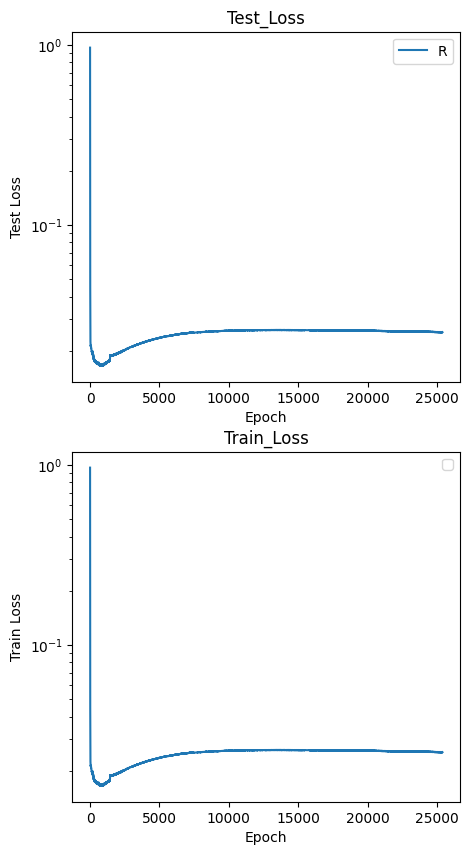

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0001 epoch:     0 , RMSE_Test: 5.42005 , RMSE_Train: 5.59680 , est_time:   0.0 min, average_time: 0.04 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0001 epoch:  1000 , RMSE_Test: 0.17132 , RMSE_Train: 0.10419 , est_time:   0.2 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0001 epoch:  2000 , RMSE_Test: 0.14886 , RMSE_Train: 0.08588 , est_time:   0.4 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0001 epoch:  3000 , RMSE_Test: 0.14429 , RMSE_Train: 0.08070 , est_time:   0.6 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0001 epoch:  4000 , RMSE_Test: 0.13923 , RMSE_Train: 0.07568 , est_time:   0.8 min, average_time: 0.01 s
act:  ReLU opt:  Ada

act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0001 epoch: 44241 , RMSE_Test: 0.22789 , RMSE_Train: 0.04324 , est_time:  10.0 min, average_time: 0.01 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691727888_RMSE_0.2278.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.0001
, epoch: 44241 , passed_time: 10.000 m , minimum_RMSE: 0.10346 , test_loss: 0.227890 , train_loss: 0.043237 , passed_time_accum: 40.089 m model_save_time 1691727888
start to save figures


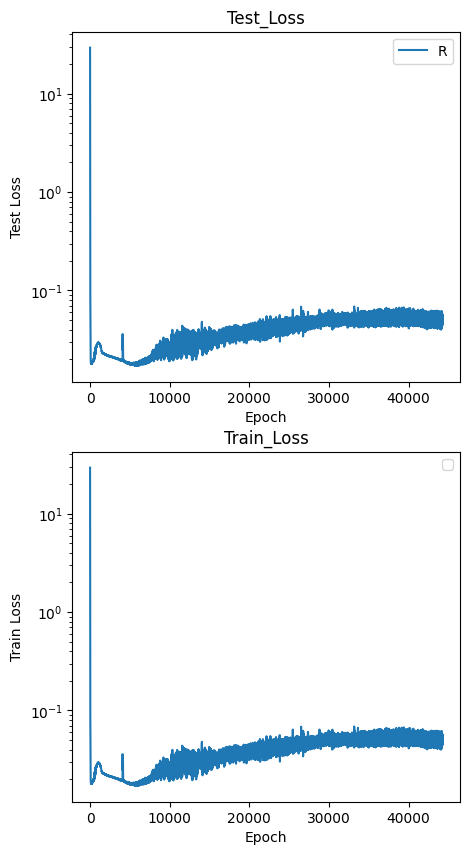

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0005 epoch:     0 , RMSE_Test: 0.52013 , RMSE_Train: 0.97110 , est_time:   0.0 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0005 epoch:  1000 , RMSE_Test: 0.20090 , RMSE_Train: 0.14194 , est_time:   0.2 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0005 epoch:  2000 , RMSE_Test: 0.17143 , RMSE_Train: 0.08662 , est_time:   0.4 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0005 epoch:  3000 , RMSE_Test: 0.17073 , RMSE_Train: 0.08150 , est_time:   0.7 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0005 epoch:  4000 , RMSE_Test: 0.17804 , RMSE_Train: 0.09042 , est_time:   0.9 min, average_time: 0.01 s
act:  ReLU opt:  Ada

act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0005 epoch: 39441 , RMSE_Test: 0.15893 , RMSE_Train: 0.03204 , est_time:  10.0 min, average_time: 0.02 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691728490_RMSE_0.1589.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.0005
, epoch: 39441 , passed_time: 10.000 m , minimum_RMSE: 0.10346 , test_loss: 0.158925 , train_loss: 0.032036 , passed_time_accum: 50.126 m model_save_time 1691728490
start to save figures


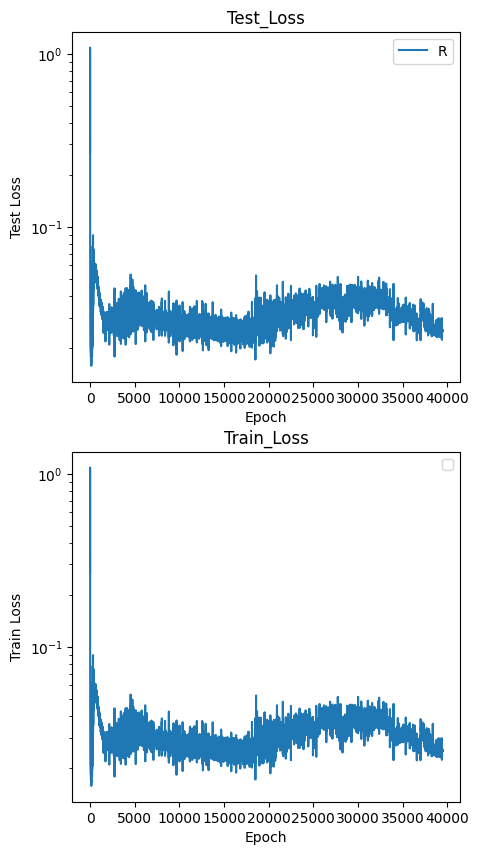

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  16 learningRate:  1e-05 epoch:     0 , RMSE_Test: 1.50479 , RMSE_Train: 1.67379 , est_time:   0.0 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  1e-05 epoch:  1000 , RMSE_Test: 0.12684 , RMSE_Train: 0.09323 , est_time:   0.2 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  1e-05 epoch:  2000 , RMSE_Test: 0.12814 , RMSE_Train: 0.09209 , est_time:   0.4 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  1e-05 epoch:  3000 , RMSE_Test: 0.13547 , RMSE_Train: 0.09337 , est_time:   0.6 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  1e-05 epoch:  4000 , RMSE_Test: 0.14408 , RMSE_Train: 0.09501 , est_time:   0.8 min, average_time: 0.01 s
act:  ReLU opt:  Adam bat

act:  ReLU opt:  Adam batch_size:  16 learningRate:  1e-05 epoch: 49745 , RMSE_Test: 0.17409 , RMSE_Train: 0.07972 , est_time:  10.0 min, average_time: 0.01 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691729093_RMSE_0.17400000000000002.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 1e-05
, epoch: 49745 , passed_time: 10.000 m , minimum_RMSE: 0.10346 , test_loss: 0.174088 , train_loss: 0.079722 , passed_time_accum: 60.162 m model_save_time 1691729093
start to save figures


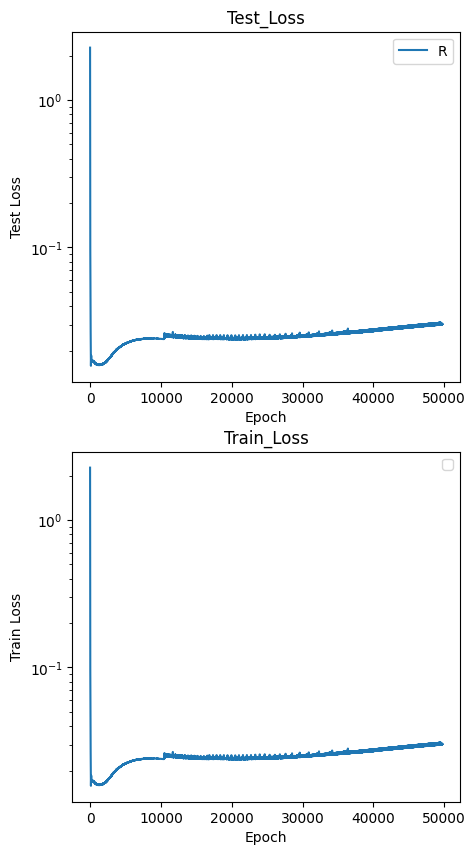

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch:     0 , RMSE_Test: 0.74702 , RMSE_Train: 0.93010 , est_time:   0.0 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch:  1000 , RMSE_Test: 0.14512 , RMSE_Train: 0.08965 , est_time:   0.1 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch:  2000 , RMSE_Test: 0.15603 , RMSE_Train: 0.07453 , est_time:   0.2 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch:  3000 , RMSE_Test: 0.14991 , RMSE_Train: 0.06418 , est_time:   0.4 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch:  4000 , RMSE_Test: 0.15395 , RMSE_Train: 0.05909 , est_time:   0.5 min, average_time: 0.01 s
act:  ReLU opt:  Ada

act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch: 79052 , RMSE_Test: 0.14425 , RMSE_Train: 0.04656 , est_time:  10.0 min, average_time: 0.01 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691729695_RMSE_0.1442.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.0001
, epoch: 79052 , passed_time: 10.000 m , minimum_RMSE: 0.09884 , test_loss: 0.144252 , train_loss: 0.046562 , passed_time_accum: 70.207 m model_save_time 1691729695
start to save figures


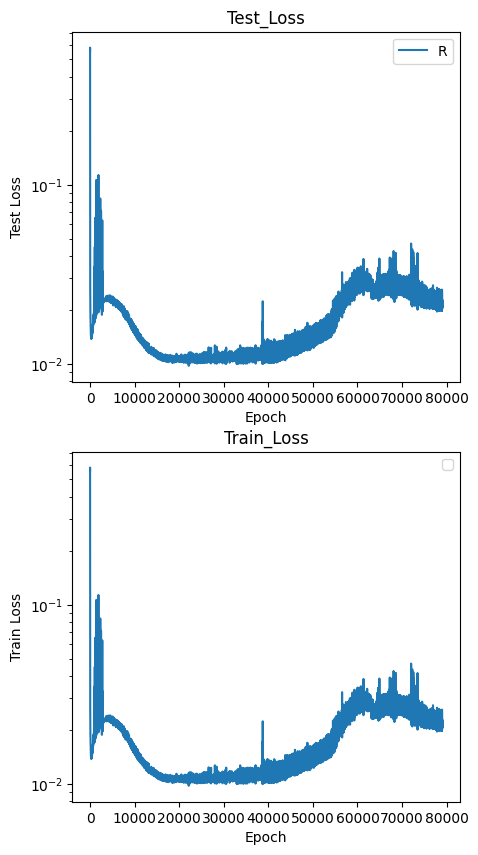

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0005 epoch:     0 , RMSE_Test: 1.31821 , RMSE_Train: 1.38563 , est_time:   0.0 min, average_time: 0.02 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0005 epoch:  1000 , RMSE_Test: 0.15056 , RMSE_Train: 0.12547 , est_time:   0.1 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0005 epoch:  2000 , RMSE_Test: 0.16799 , RMSE_Train: 0.07525 , est_time:   0.2 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0005 epoch:  3000 , RMSE_Test: 0.14583 , RMSE_Train: 0.09883 , est_time:   0.4 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0005 epoch:  4000 , RMSE_Test: 0.15506 , RMSE_Train: 0.07949 , est_time:   0.5 min, average_time: 0.01 s
act:  ReLU opt:  Ada

act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0005 epoch: 67359 , RMSE_Test: 0.14582 , RMSE_Train: 0.02946 , est_time:  10.0 min, average_time: 0.01 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691730297_RMSE_0.1458.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.0005
, epoch: 67359 , passed_time: 10.001 m , minimum_RMSE: 0.09884 , test_loss: 0.145825 , train_loss: 0.029464 , passed_time_accum: 80.242 m model_save_time 1691730297
start to save figures


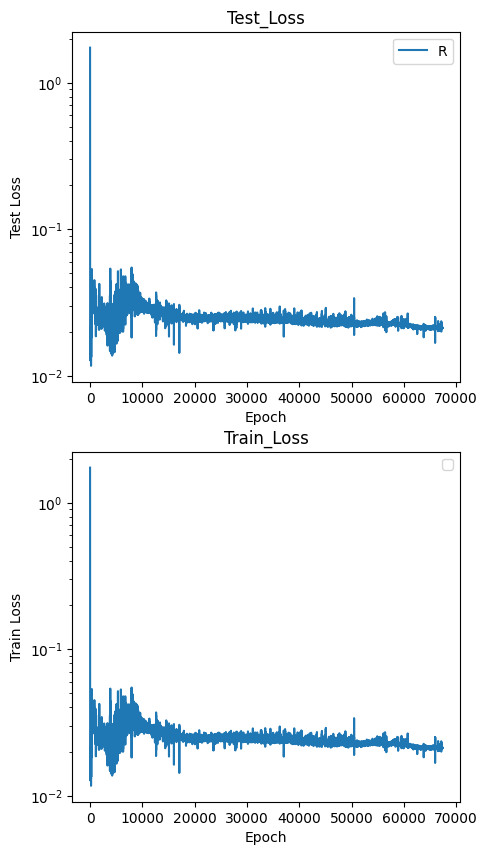

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  32 learningRate:  1e-05 epoch:     0 , RMSE_Test: 1.32732 , RMSE_Train: 1.28456 , est_time:   0.0 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  1e-05 epoch:  1000 , RMSE_Test: 0.13036 , RMSE_Train: 0.09817 , est_time:   0.1 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  1e-05 epoch:  2000 , RMSE_Test: 0.12335 , RMSE_Train: 0.08870 , est_time:   0.2 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  1e-05 epoch:  3000 , RMSE_Test: 0.12449 , RMSE_Train: 0.08684 , est_time:   0.3 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  1e-05 epoch:  4000 , RMSE_Test: 0.13101 , RMSE_Train: 0.08754 , est_time:   0.5 min, average_time: 0.01 s
act:  ReLU opt:  Adam bat

act:  ReLU opt:  Adam batch_size:  32 learningRate:  1e-05 epoch: 82582 , RMSE_Test: 0.16476 , RMSE_Train: 0.06486 , est_time:  10.0 min, average_time: 0.01 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691730900_RMSE_0.1647.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 1e-05
, epoch: 82582 , passed_time: 10.000 m , minimum_RMSE: 0.09884 , test_loss: 0.164764 , train_loss: 0.064864 , passed_time_accum: 90.280 m model_save_time 1691730900
start to save figures


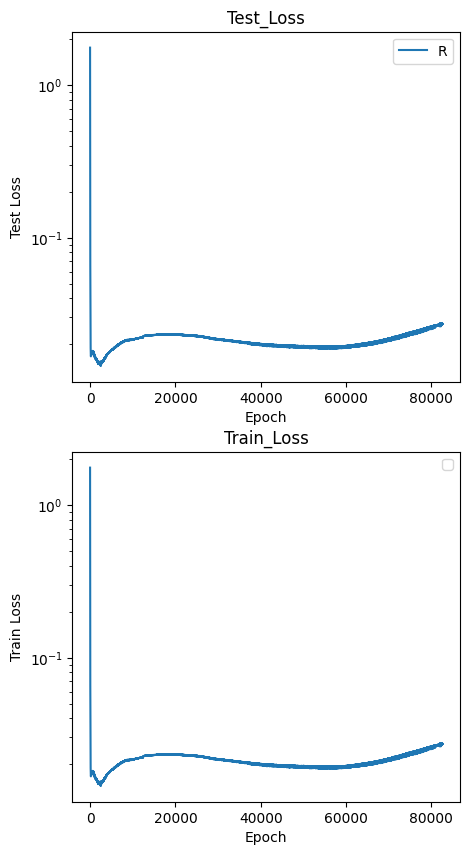

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0001 epoch:     0 , RMSE_Test: 13.70497 , RMSE_Train: 14.70067 , est_time:   0.0 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0001 epoch:  1000 , RMSE_Test: 0.15734 , RMSE_Train: 0.12345 , est_time:   0.1 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0001 epoch:  2000 , RMSE_Test: 0.14209 , RMSE_Train: 0.11037 , est_time:   0.1 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0001 epoch:  3000 , RMSE_Test: 0.16058 , RMSE_Train: 0.09683 , est_time:   0.2 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0001 epoch:  4000 , RMSE_Test: 0.16021 , RMSE_Train: 0.09151 , est_time:   0.3 min, average_time: 0.00 s
act:  ReLU opt:  A

act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0001 epoch: 145628 , RMSE_Test: 0.16229 , RMSE_Train: 0.05653 , est_time:  10.0 min, average_time: 0.00 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691731502_RMSE_0.1622.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.0001
, epoch: 145628 , passed_time: 10.000 m , minimum_RMSE: 0.09884 , test_loss: 0.162285 , train_loss: 0.056528 , passed_time_accum: 100.312 m model_save_time 1691731502
start to save figures


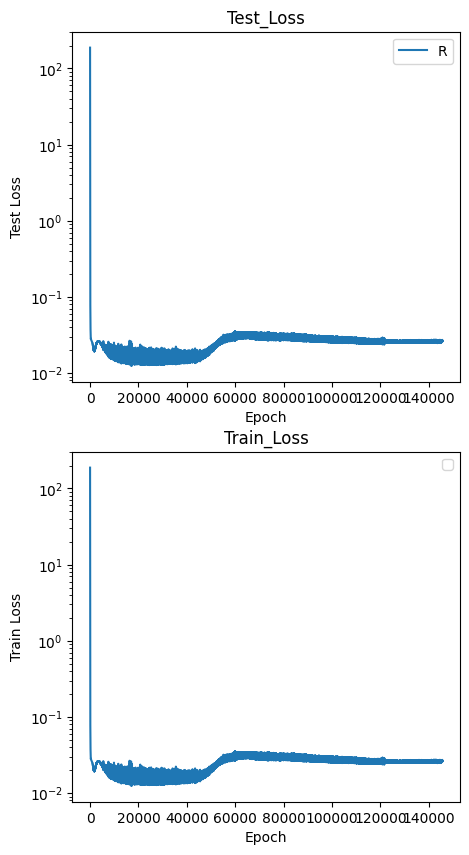

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0005 epoch:     0 , RMSE_Test: 5.20875 , RMSE_Train: 6.28874 , est_time:   0.0 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0005 epoch:  1000 , RMSE_Test: 0.13017 , RMSE_Train: 0.11834 , est_time:   0.1 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0005 epoch:  2000 , RMSE_Test: 0.16588 , RMSE_Train: 0.10405 , est_time:   0.1 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0005 epoch:  3000 , RMSE_Test: 0.14417 , RMSE_Train: 0.10507 , est_time:   0.2 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0005 epoch:  4000 , RMSE_Test: 0.14110 , RMSE_Train: 0.08627 , est_time:   0.3 min, average_time: 0.00 s
act:  ReLU opt:  Ada

act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0005 epoch: 121762 , RMSE_Test: 0.15868 , RMSE_Train: 0.04226 , est_time:  10.0 min, average_time: 0.00 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691732105_RMSE_0.15860000000000002.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.0005
, epoch: 121762 , passed_time: 10.000 m , minimum_RMSE: 0.09884 , test_loss: 0.158683 , train_loss: 0.042260 , passed_time_accum: 110.362 m model_save_time 1691732105
start to save figures


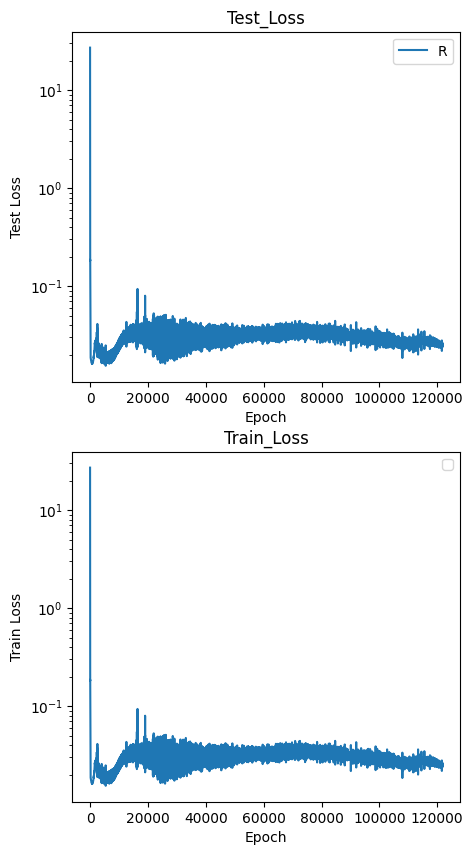

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  64 learningRate:  1e-05 epoch:     0 , RMSE_Test: 2.48992 , RMSE_Train: 2.55405 , est_time:   0.0 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  1e-05 epoch:  1000 , RMSE_Test: 0.12779 , RMSE_Train: 0.11984 , est_time:   0.1 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  1e-05 epoch:  2000 , RMSE_Test: 0.12740 , RMSE_Train: 0.11745 , est_time:   0.2 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  1e-05 epoch:  3000 , RMSE_Test: 0.12699 , RMSE_Train: 0.11494 , est_time:   0.3 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  64 learningRate:  1e-05 epoch:  4000 , RMSE_Test: 0.12713 , RMSE_Train: 0.11232 , est_time:   0.3 min, average_time: 0.01 s
act:  ReLU opt:  Adam bat

act:  ReLU opt:  Adam batch_size:  64 learningRate:  1e-05 epoch: 136790 , RMSE_Test: 0.12246 , RMSE_Train: 0.06772 , est_time:  10.0 min, average_time: 0.00 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691732707_RMSE_0.12240000000000001.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 1e-05
, epoch: 136790 , passed_time: 10.000 m , minimum_RMSE: 0.09884 , test_loss: 0.122460 , train_loss: 0.067721 , passed_time_accum: 120.406 m model_save_time 1691732707
start to save figures


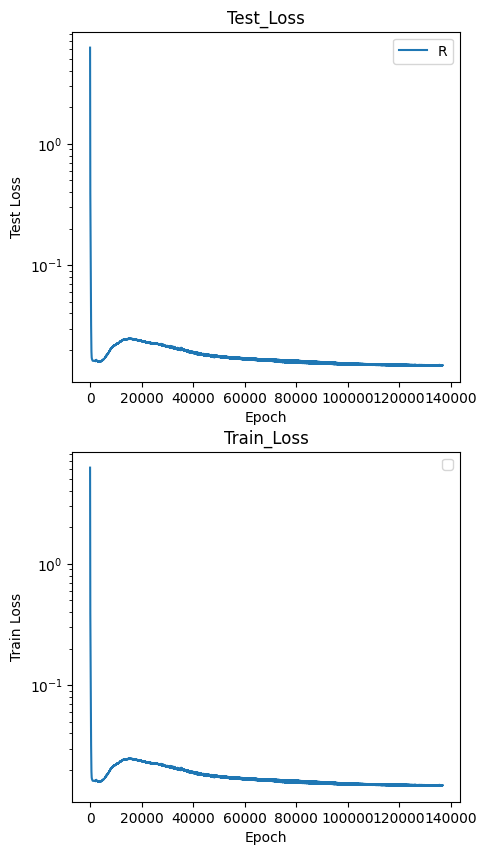

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0001 epoch:     0 , RMSE_Test: 1.63590 , RMSE_Train: 2.07342 , est_time:   0.0 min, average_time: 0.01 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0001 epoch:  1000 , RMSE_Test: 0.13602 , RMSE_Train: 0.27239 , est_time:   0.0 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0001 epoch:  2000 , RMSE_Test: 0.15835 , RMSE_Train: 0.17552 , est_time:   0.1 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0001 epoch:  3000 , RMSE_Test: 0.15599 , RMSE_Train: 0.11216 , est_time:   0.1 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0001 epoch:  4000 , RMSE_Test: 0.14374 , RMSE_Train: 0.09005 , est_time:   0.2 min, average_time: 0.00 s
act:  ReLU opt:

act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0001 epoch: 221214 , RMSE_Test: 0.18039 , RMSE_Train: 0.05549 , est_time:  10.0 min, average_time: 0.00 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691733310_RMSE_0.18030000000000002.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.0001
, epoch: 221214 , passed_time: 10.000 m , minimum_RMSE: 0.09884 , test_loss: 0.180385 , train_loss: 0.055494 , passed_time_accum: 130.449 m model_save_time 1691733310
start to save figures


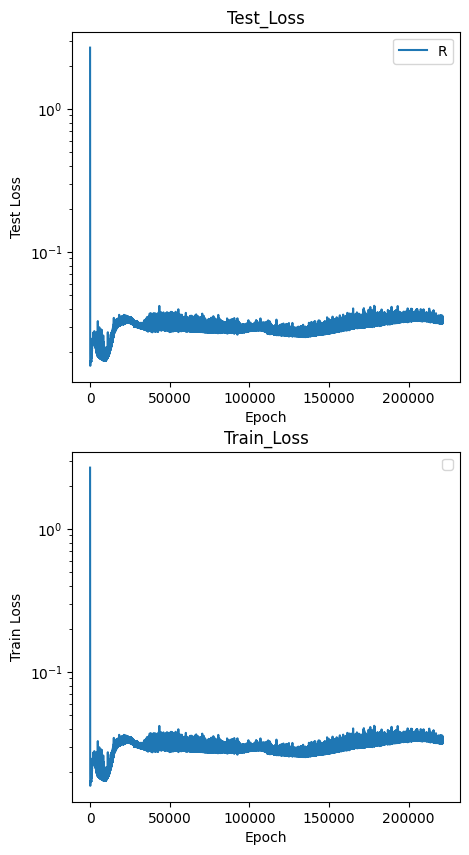

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0005 epoch:     0 , RMSE_Test: 2.92492 , RMSE_Train: 4.34072 , est_time:   0.0 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0005 epoch:  1000 , RMSE_Test: 0.16601 , RMSE_Train: 0.19145 , est_time:   0.0 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0005 epoch:  2000 , RMSE_Test: 0.16128 , RMSE_Train: 0.14230 , est_time:   0.1 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0005 epoch:  3000 , RMSE_Test: 0.13714 , RMSE_Train: 0.09800 , est_time:   0.1 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0005 epoch:  4000 , RMSE_Test: 0.14129 , RMSE_Train: 0.09390 , est_time:   0.2 min, average_time: 0.00 s
act:  ReLU opt:

act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0005 epoch: 205375 , RMSE_Test: 0.19718 , RMSE_Train: 0.04623 , est_time:  10.0 min, average_time: 0.00 s
start to save model
start to save log
/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model1691733912_RMSE_0.1971.pt data: /content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/inputData.xlsx
, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.0005
, epoch: 205375 , passed_time: 10.000 m , minimum_RMSE: 0.09884 , test_loss: 0.197181 , train_loss: 0.046232 , passed_time_accum: 140.493 m model_save_time 1691733912
start to save figures


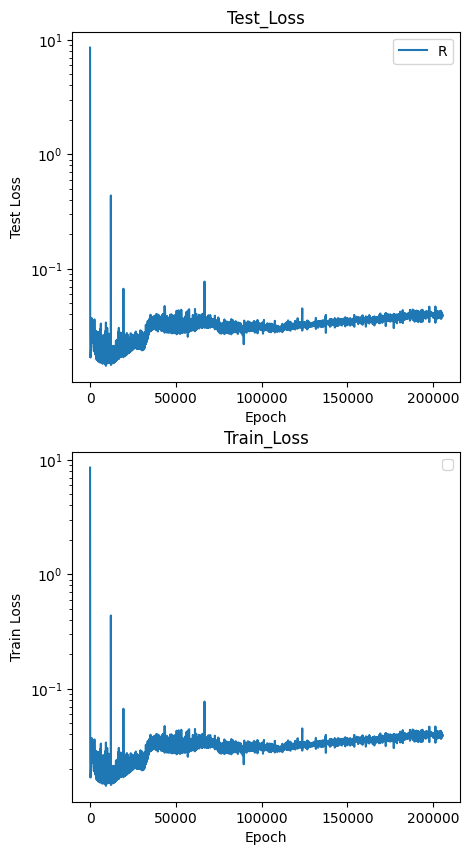

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  128 learningRate:  1e-05 epoch:     0 , RMSE_Test: 14.48171 , RMSE_Train: 14.50863 , est_time:   0.0 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  1e-05 epoch:  1000 , RMSE_Test: 0.58203 , RMSE_Train: 0.60686 , est_time:   0.0 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  1e-05 epoch:  2000 , RMSE_Test: 0.28822 , RMSE_Train: 0.45029 , est_time:   0.1 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  1e-05 epoch:  3000 , RMSE_Test: 0.18205 , RMSE_Train: 0.40953 , est_time:   0.1 min, average_time: 0.00 s
act:  ReLU opt:  Adam batch_size:  128 learningRate:  1e-05 epoch:  4000 , RMSE_Test: 0.14723 , RMSE_Train: 0.39441 , est_time:   0.2 min, average_time: 0.00 s
act:  ReLU opt:  A

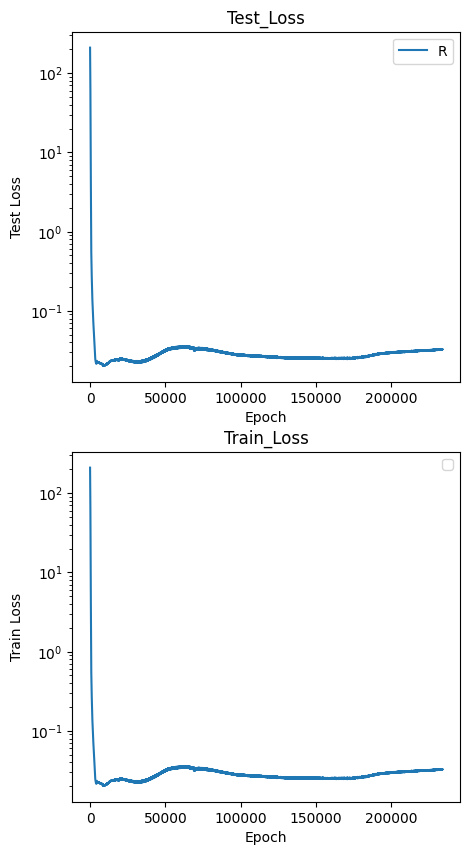

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

These parameters showed the best performance!--------------------------------------------------------------------------------
('/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/model_1691729695_best_0.0988.pt', ', layer_dim_list:', [6, 100, 100, 10, 1], 'activateion:', 'ReLU', ', optimizer:', 'Adam', ', Bsize:', 32, ', learningRate:', 0.0001, ', epoch: 22143', ', passed_time: 2.656', 'm', ', minimum_RMSE: 0.00977', ', test_loss: 0.009770', ', train_loss: 0.002656', ', passed_time_accum: 62.863', 'm')
all done


'\n\n\n\n, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.0001\n, epoch:  2848 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.013069 , train_loss: 0.004550 , passed_time_accum: 7.201 m model_save_time 1691666246\n\n, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.0005\n, epoch:  2916 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.014663 , train_loss: 0.005586 , passed_time_accum: 8.222 m model_save_time 1691666308\n\n, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 1e-05\n, epoch:  3024 , passed_time: 1.000 m , minimum_RMSE: 0.02 , test_loss: 0.015070 , train_loss: 0.005430 , passed_time_accum: 9.254 m model_save_time 1691666370\n\n\n\n\n, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.0001\n, epoch:  4708 , passed_time: 1.000 m , minimum_RMSE: 0.

In [ ]:

#default

"""

"""
# for learningRate in range(10): #


# dim_list = [2, 100, 100, 100, 10, 1] 10 min: 0.03 loss
dim_list = [6, 100, 100, 10, 1]


f = open("/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/log.txt", "a")
#If data is less complex and is having fewer dimensions or features then neural networks with 1 to 2 hidden layers would work.
# If data is having large dimensions or features then to get an optimum solution, 3 to 5 hidden layers can be used.

init_time = time.time()
best_record = ''
best_mse = np.inf   # init to infinity
best_weights = None
print('start')

for act in [
            # 'LeakyReLU',
            # 'LogSigmoid',
            # 'Softplus'
            'ReLU'
            ]:

    for opt in [
                # 'Adadelta',
                # 'Adagrad',
                'Adam',
                # 'AdamW',
                # 'SparseAdam',
                # 'Adamax',
                # 'ASGD',
                # 'LBFGS',
                # 'NAdam',
                # 'RAdam',
                # 'RMSprop',
                # 'Rprop',
                # 'SGD'
                ]:

        for batch_size in [ 8, 16, 32, 64, 128]:
        # for Bsize in [ 10, 100, 1000]:
        # for batch_size in [ 8 ]:

            # for learningRate in [ 1e-1, 1e-2, 1e-3, 1e-4,1e-5, 1e-6, ]:
            # for learningRate in [ 1e-1, 5e-1, 1e-2, 5e-2, 1e-3, 5e-3, 1e-4, 5e-4, 1e-5, 5e-5, 1e-6, 5e-6, ]:
            for learningRate in [  0.0001, 0.0005, 1e-5 ]:
                try:
                    make_model = 'model = nn.Sequential('
                    for layer_num in range( len(dim_list) - 1 ):
                        if layer_num == len(dim_list) - 2:
                            make_model = make_model + 'nn.Linear(dim_list[' + str(layer_num) + '], dim_list[' + str(layer_num+1) + ']) )'
                        else:
                            # make_model = make_model + 'nn.Linear(dim_list[' + str(layer_num) + '], dim_list[' + str(layer_num+1) + ']), nn.LeakyReLU(),'
                            make_model = make_model + 'nn.Linear(dim_list[' + str(layer_num) + '], dim_list[' + str(layer_num+1) + ']), nn.' + act + '(),'


                    exec(make_model)

                    exec('optimizer = optim.' + opt + '(model.parameters(), lr=learningRate  )')

                    batch_start = torch.arange(0, len(X_train), batch_size)

                    # Hold the best model

                    history = []
                    history_train = []


                    # for epoch in range(n_epochs):
                    second_time = time.time()

                    epoch = 0
                    len_batch = len(X_train)
                    loss_func = nn.MSELoss()
                    while(1):

                        model.train()

                        for start in range(0,len_batch, batch_size):

                            X_batch = X_train[start:start+batch_size] # 두번째 값이 길이를 초과해도 오류안뜨고 그냥 시작부터 끝까지 출력해주는 착한친구.
                            y_batch = y_train[start:start+batch_size]
                            # forward pass
                            y_pred = model(X_batch).squeeze()

                            # before_loss = torch.mean( (y_pred/y_batch-1)**2 + (y_batch/y_pred-1)**2 + (y_pred-y_batch)**2 )
                            # before_loss = torch.mean( (y_pred/y_batch-1)**2 + (y_batch/y_pred-1)**2  )

                            # loss = before_loss**(1/2)
                            loss = loss_func(y_pred,y_batch )

                            # backward pass
                            optimizer.zero_grad()
                            loss.backward()

                            # update weights
                            optimizer.step()

                        loss = float(loss)

                        history_train.append(loss)

                        model.eval()
                        y_pred = model(X_test).squeeze()
                        #print(y_pred)

                        # before_loss = torch.mean(  (y_pred/y_test-1)**2 + (y_test/y_pred-1)**2 + (y_pred-y_test)**2 )
                        # before_loss = torch.mean(  (y_pred/y_test-1)**2 + (y_test/y_pred-1)**2   )

                        # mse = before_loss**(1/2)
                        mse = loss_func(y_pred, y_test)

                        mse = float(mse)

                        history.append(mse)
                        if mse < best_mse:
                            best_mse = mse
                            # best_weights = copy.deepcopy(model.state_dict())
                            model_file_name = '/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/'+'model_' + str(int(second_time)) + '_best_' + str( ((best_mse**(1/2))//0.0001)*0.0001 ) + '.pt'
                            torch.save(model, model_file_name )
                            best_record =  (
                                            model_file_name,

                                            ', layer_dim_list:', dim_list,
                                            'activateion:', act,
                                            ', optimizer:', opt,
                                            ', Bsize:', batch_size ,
                                            ', learningRate:', learningRate ,

                                            ', epoch: %5d' % epoch,
                                            ', passed_time: %.3f' % ( ( ( time.time()-second_time ) )  / 60  ),  'm',

                                            ", minimum_RMSE: %.5f" % (best_mse),
                                            ', test_loss: %5f' % (mse),
                                            ', train_loss: %5f' % (loss),
                                            ', passed_time_accum: %.3f' % ( ( time.time() -init_time )  / 60  ),  'm',

                                            )

                        if epoch % 1000 == 0:
                            # print('epoch: %5d' % epoch, 'test_loss: %.2f' % (mse), 'train_loss: %.2f' % (loss), 'est_time: %.2f' % (( ( epoch_time ) / (epoch+1) ) / 60 * (n_epochs-epoch) ) ,'min', "epoch_time:", epoch_time, 's')
                            print_progress(act, opt, batch_size, learningRate, epoch, mse, loss, second_time)
                            # print('{:.6}'.format(val))
                            # print("{:10.4f}".format(x))

                        # if (mse<10) or (str(mse)=='nan') or ( ( ( time.time()-second_time ) )  / 60 > 0.1  ):
                        # if (mse**(1/2) < 0.005) or (str(mse)=='nan'): # 1~10 까지의 값 중에서  E 의 최솟값은 0.05이다. 그런데 이 값의 1퍼센트 오차인
                        if (mse**(1/2) < 0.005) or (str(mse)=='nan') or ( ( ( time.time()-second_time ) )  / 60 > 10 ):
                            print_progress(act, opt, batch_size, learningRate, epoch, mse, loss, second_time)
                            save_my_work(model, f, data_path, opt, batch_size, learningRate, epoch, second_time, best_mse, mse, loss, init_time)
                            break
                        epoch = epoch + 1

                    # restore model and return best accuracy
                    # model.load_state_dict(best_weights)
                    # print("MSE: %.2f" % best_mse)
                    # print("RMSE: %.2f" % np.sqrt(best_mse))


                    print('finish--------------------------------------------------------------------------------------------------------------------------------------------------------')
                    print('')

                except:
                    # os.mkdir('/content/drive/MyDrive/0_318lab/SCMP_ML/')
                    print('error has occured')
                    save_my_work(model, f, data_path, opt, batch_size, learningRate, epoch, second_time, best_mse, mse, loss, init_time)

f.close()
print('These parameters showed the best performance!--------------------------------------------------------------------------------')
print(best_record)
print('all done')
# ----------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------
'''



, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.0001
, epoch:  2848 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.013069 , train_loss: 0.004550 , passed_time_accum: 7.201 m model_save_time 1691666246

, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.0005
, epoch:  2916 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.014663 , train_loss: 0.005586 , passed_time_accum: 8.222 m model_save_time 1691666308

, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 1e-05
, epoch:  3024 , passed_time: 1.000 m , minimum_RMSE: 0.02 , test_loss: 0.015070 , train_loss: 0.005430 , passed_time_accum: 9.254 m model_save_time 1691666370




, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.0001
, epoch:  4708 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.014034 , train_loss: 0.010796 , passed_time_accum: 19.587 m model_save_time 1691666990

, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.0005
, epoch:  5139 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.013336 , train_loss: 0.004654 , passed_time_accum: 20.617 m model_save_time 1691667051

, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 1e-05
, epoch:  5155 , passed_time: 1.000 m , minimum_RMSE: 0.02 , test_loss: 0.015753 , train_loss: 0.012467 , passed_time_accum: 21.677 m model_save_time 1691667115





, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.0001
, epoch:  9675 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.016833 , train_loss: 0.006455 , passed_time_accum: 32.000 m model_save_time 1691667734

, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.0005
, epoch:  9312 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.013732 , train_loss: 0.002845 , passed_time_accum: 33.021 m model_save_time 1691667796

, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 1e-05
, epoch:  9481 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.011938 , train_loss: 0.007625 , passed_time_accum: 34.054 m model_save_time 1691667858




, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.0001
, epoch: 17629 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.014780 , train_loss: 0.006395 , passed_time_accum: 44.424 m model_save_time 1691668480

, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.0005
, epoch: 16380 , passed_time: 1.001 m , minimum_RMSE: 0.01 , test_loss: 0.018041 , train_loss: 0.004769 , passed_time_accum: 45.451 m model_save_time 1691668541

, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 1e-05
, epoch: 17691 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.012093 , train_loss: 0.008359 , passed_time_accum: 46.491 m model_save_time 1691668604




, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.0001
, epoch: 29010 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.015565 , train_loss: 0.005232 , passed_time_accum: 56.873 m model_save_time 1691669227

, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.0005
, epoch: 28989 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.011081 , train_loss: 0.004711 , passed_time_accum: 57.899 m model_save_time 1691669288

, layer_dim_list: [6, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 1e-05
, epoch: 29884 , passed_time: 1.000 m , minimum_RMSE: 0.01 , test_loss: 0.012395 , train_loss: 0.009735 , passed_time_accum: 58.936 m model_save_time 1691669350



'''


In [ ]:
model.eval()
y_pred = model(X_test).squeeze()
print(y_pred)
print(y_test)


In [ ]:
136*2

In [ ]:
# %%capture cap
f = open("/content/drive/MyDrive/0_318lab/SCMP_ML/log.txt", "a")
print(
                        datetime.now(),
                        'data:', xdata_name,
                        ', layer_dim_list:', dim_list,
                      'activateion:', act,
                      ', optimizer:', opt,
                      ', n_of_data:',N,
                      ', Bsize:', Bsize ,
                      ', learningRate:', learningRate ,
                      file=f
                      )
print(
                      ', epoch: %5d' % epoch,
                      ', passed_time: %.3f' % ( ( ( time.time()-second_time ) )  / 60  ),  'm',

                      ", minimum_RMSE: %.2f" % (best_mse),
                      ', test_loss: %2f' % (mse),
                      ', train_loss: %2f' % (loss),
                      ', passed_time_accum: %.3f' % ( ( init_time - time.time() )  / 60  ),  'm',
                      file=f
                      )
# print(cap, file=f)
f.close()

In [ ]:
N, D_in, D_out = 100, 2, 1

mass_num = [0.1, 1, 5, 10, 15, 20]
len_mass_num = len(mass_num)
fig, axs = plt.subplots(len_mass_num, 1, figsize=(5, 5*len_mass_num))#, sharey=True)
for k in range(len_mass_num):
    # m =1
    X2 = []
    y2 = []
    for j in range(N):
        X2.append([])
        #y.append([])
        for i in range(D_out):
            X2[-1].append( mass_num[k] )
            X2[-1].append( np.random.uniform(low=-10.0, high=10.0, size=None) )
            y2.append( (X2[-1][-1]**2) / (2*X2[-1][-2])  )


    X2 = torch.Tensor(X2)
    y2 = torch.Tensor(y2)



    model.eval()
    y_pred = model(X2)


    axs[k].scatter(X2[:,1], y2, label="E=p^2/(2m), m="+str(mass_num[k])+"", s=1)
    axs[k].scatter(X2[:,1].cpu().detach().numpy(), y_pred.cpu().detach().numpy(), label="predict", s=1)
    axs[k].legend()
    axs[k].set_xlabel('Momentum', fontsize=10)
    axs[k].set_ylabel(r'Energy', fontsize=10)
    # plt.ylabel("Y", rotation=0)
    axs[k].set_title('Constant Mass')

# plt.subplots_adjust(bottom=0.1, right=1, top=1.5)
    # axs[2].plot(names, values)
# fig.suptitle('Constant mass')


# ax.set_title('Volume and percent change')
# plt.savefig('/content/drive/MyDrive/0_318lab/SCMP_ML/figures/' + str('test') + '.png')
plt.savefig(
            '/content/drive/MyDrive/0_318lab/SCMP_ML/figures/' + str('P-E') + '_TestLoss_' + str(int(mse)) + '_TrainLoss_' + str(int(loss)) + '_'+str(int(time.time()))+'.pdf',
            format="pdf",
            bbox_inches="tight")

plt.show()



p_num = [20, -15, -10, -5, -1, -0.1, 0.1, 1, 5, 10, 15, 20]
len_p_num = len(p_num)
fig, axs = plt.subplots(len_p_num, 1, figsize=(5, 5*len_p_num))#, sharey=True)
for k in range(len_p_num):

    # p =1
    X3 = []
    y3 = []
    for j in range(N):
        X3.append([])
        #y.append([])
        for i in range(D_out):
            X3[-1].append( np.random.uniform(low=0.1, high=10.0, size=None) )
            X3[-1].append( p_num[k] )
            y3.append( (X3[-1][-1]**2) / (2*X3[-1][-2])  )


    X3 = torch.Tensor(X3)
    y3 = torch.Tensor(y3)


# model.eval()
# y_pred = model(X3)
# plt.scatter(X3[:,0].cpu().detach().numpy(),y_pred.cpu().detach().numpy(), marker='*')
# # plt.scatter(X3[:,1],y_pred, marker='*')
# plt.show()


# plt.scatter(X3[:,0] ,y3, marker='.', )
# plt.show()

# plt.scatter(X3[:,0].cpu().detach().numpy(),y_pred.cpu().detach().numpy(), marker='*')
# plt.scatter(X3[:,0] ,y3, marker='.', )
# plt.show()
    model.eval()
    y_pred = model(X3)
    axs[k].scatter(X3[:,0], y3, label="E=p^2/(2m), p="+str(p_num[k])+"", s=1)
    axs[k].scatter(X3[:,0].cpu().detach().numpy(), y_pred.cpu().detach().numpy(), label="predict", s=1)
    axs[k].legend()
    axs[k].set_xlabel('Momentum', fontsize=10)
    axs[k].set_ylabel(r'Energy', fontsize=10)
    # plt.ylabel("Y", rotation=0)
    axs[k].set_title('Constant Mass')

# plt.subplots_adjust(bottom=0.1, right=1, top=2)
    # axs[2].plot(names, values)
# fig.suptitle('Constant mass')


# ax.set_title('Volume and percent change')
# plt.savefig('/content/drive/MyDrive/0_318lab/SCMP_ML/figures/' + str('test') + '.png')
plt.savefig(
            '/content/drive/MyDrive/0_318lab/SCMP_ML/figures/' + str('M-E') + '_TestLoss_' + str(int(mse)) + '_TrainLoss_' + str(int(loss)) + '_'+str(int(time.time()))+'.pdf',
            format="pdf",
            bbox_inches="tight")

plt.show()





print('all done')



In [ ]:
plt.plot(history)
plt.yscale('log')
plt.title('test_loss')
plt.show()

plt.plot(history_train)
plt.title('train_loss')
plt.yscale('log')
plt.show()

In [ ]:
# when create new data

# N, D_in, H, D_out = 64, 1000, 100, 10
for m in [10, 100, 1000]:
    for k in [1000, 10000, 100000]:
        N, D_in, D_out = k, 2, 1

        # 입력과 출력 위한 랜덤 텐서
        X = []
        y = []
        for j in range(N):
            X.append([])
            #y.append([])
            for i in range(D_out):
                X[-1].append( np.random.uniform(low=0.1, high=10.0, size=None) )
                X[-1].append( np.random.uniform(low=-m, high=m, size=None) )
                y.append( (X[-1][-1]**2) / (2*X[-1][-2])  )


        X = torch.Tensor(X)
        y = torch.Tensor(y)

        # nn package를 이용하여 여러 층으로 정의된 모델 생성
        # nn.Sequential은 다른 모듈을 담을 수 있는 모듈이며 담겨진 모듈은 순서대로 연결
        # Linear 모듈은 곧 Affine 모듈

        # Read data
        # data = fetch_california_housing()
        # X, y = data.data, data.target

        # train-test split for model evaluation

        # import time
        # >>> # Save to file
        # >>> x = torch.tensor([0, 1, 2, 3, 4])
        # >>> torch.save(x, 'tensor.pt')

        torch.save(X, '/content/drive/MyDrive/0_318lab/SCMP_ML/'+'KEdataX_N_'+ str(N) +'_Interval_'+str(m)+'_'+str(int(time.time()))+'.pt' )
        torch.save(y, '/content/drive/MyDrive/0_318lab/SCMP_ML/'+'KEdataY_N_'+ str(N) +'_Interval_'+str(m)+'_'+str(int(time.time()))+'.pt' )
